In [1]:
# ============================================================================
# SPEC 0 — Imports + Global Configuration
# ============================================================================

# --- Standard Libraries ---
import warnings
warnings.filterwarnings('ignore')

# --- Numerical Computing & Data Handling ---
import numpy as np
import pandas as pd

# --- Visualization Libraries ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Scikit-Learn: Preprocessing ---
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

# --- Scikit-Learn: Model Selection ---
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import GroupKFold

# --- Scikit-Learn: Metrics ---
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- Scikit-Learn: Models ---
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

# --- Optional: Advanced Libraries (uncomment if needed) ---
# import xgboost as xgb
# import lightgbm as lgb
# import shap
from scipy import stats

# ============================================================================
# Global Configuration
# ============================================================================

# Random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Default figure size for plots
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# Set plotting style
sns.set_style("whitegrid")
sns.set_palette("husl")

# ============================================================================
# Helper Functions
# ============================================================================

def compute_rmse(y_true, y_pred):
    """
    Compute Root Mean Squared Error (RMSE).

    Parameters:
    -----------
    y_true : array-like
        Ground truth target values
    y_pred : array-like
        Predicted target values

    Returns:
    --------
    rmse : float
        Root Mean Squared Error
    """
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Print configuration summary
print("Imports loaded successfully")
print(f"Random seed set to: {RANDOM_SEED}")
print(f"Default figure size: {plt.rcParams['figure.figsize']}")
print("Configuration complete - ready for EDA and modeling")


Imports loaded successfully
Random seed set to: 42
Default figure size: [12.0, 6.0]
Configuration complete - ready for EDA and modeling


In [2]:
# ============================================================================
# Load Dataset & Initial Exploration
# ============================================================================

# Load the Spotify dataset
df = pd.read_csv('ee_344_final_project.csv')

print("=" * 80)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 80)

# 1. Print Dataset Shape
print(f"\nDataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

# 2. Print Column Names
print(f"\nColumn Names ({len(df.columns)} total):")
print(list(df.columns))

# 3. Print Data Types
print(f"\nData Types:")
print(df.dtypes)

# 4. Compute Missing Values
print(f"\nMissing Values:")
missing_counts = df.isnull().sum()
missing_df = pd.DataFrame({
    'Column': missing_counts.index,
    'Missing_Count': missing_counts.values,
    'Missing_Percentage': (missing_counts.values / len(df) * 100).round(2)
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
if len(missing_df) > 0:
    print(missing_df.to_string(index=False))
else:
    print("No missing values found!")

# 5. Check for Duplicate Rows
duplicate_count = df.duplicated().sum()
print(f"\nDuplicate Rows: {duplicate_count:,} ({duplicate_count/len(df)*100:.2f}%)")

# 6. Create Summary Table: Column Name | Data Type | Missing Count
print(f"\nColumn Summary Table:")
summary_table = pd.DataFrame({
    'Column': df.columns,
    'Data_Type': df.dtypes.values,
    'Missing_Count': df.isnull().sum().values,
    'Missing_Percentage': (df.isnull().sum().values / len(df) * 100).round(2)
})
print(summary_table.to_string(index=False))

# 7. Identify Column Types
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()

# Check for potential text columns (object columns with many unique values)
potential_text_cols = []
for col in categorical_cols:
    unique_ratio = df[col].nunique() / len(df)
    if unique_ratio > 0.5:  # More than 50% unique values suggests text/ID
        potential_text_cols.append(col)

print(f"\nNumeric Columns ({len(numeric_cols)}):")
print(numeric_cols)

print(f"\nCategorical Columns ({len(categorical_cols)}):")
print(categorical_cols)

if potential_text_cols:
    print(f"\nPotential Text/ID Columns ({len(potential_text_cols)}):")
    print(potential_text_cols)

# 8. Identify Target Column
target_col = 'popularity'
if target_col in df.columns:
    print(f"\nTarget Column: '{target_col}'")

    # Check range of popularity
    print(f"\nPopularity Statistics:")
    print(df[target_col].describe())

    print(f"\nPopularity Range:")
    print(f"  Min: {df[target_col].min()}")
    print(f"  Max: {df[target_col].max()}")
    print(f"  Mean: {df[target_col].mean():.2f}")
    print(f"  Median: {df[target_col].median():.2f}")
    print(f"  Std: {df[target_col].std():.2f}")

    # Check for impossible values (popularity should be 0-100)
    impossible_values = df[(df[target_col] < 0) | (df[target_col] > 100)]
    if len(impossible_values) > 0:
        print(f"\nWARNING: Found {len(impossible_values)} rows with popularity outside [0, 100]")
    else:
        print(f"\nPopularity values are within valid range [0, 100]")
else:
    print(f"\nWARNING: Target column '{target_col}' not found!")

# 9. Display First Few Rows
print(f"\nFirst 5 Rows:")
df.head()


DATASET LOADED SUCCESSFULLY

Dataset Shape: 114,000 rows × 21 columns

Column Names (21 total):
['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']

Data Types:
Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object

Missing Valu

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


# Initial Data Exploration Discussion

## Guiding Questions:

1. Is popularity evenly distributed or skewed?

2. Are there structural issues (missing values, duplicates) that need to be addressed?

3. Are some features clearly categorical vs continuous, and which ones should be encoded?

4. Are any columns redundant or clearly IDs that should be dropped before modeling?

5. Are there any impossible or suspicious values that need to be handled?

In [3]:
# ============================================================================
# Analysis 1: Popularity Distribution
# ============================================================================

# Calculate skewness
skewness = stats.skew(df['popularity'])
print(f"\nSkewness: {skewness:.3f}")
if abs(skewness) < 0.5:
    print("Interpretation: Approximately symmetric distribution")
elif abs(skewness) < 1:
    print("Interpretation: Moderately skewed distribution")
else:
    print("Interpretation: Highly skewed distribution")

if skewness > 0:
    print("Direction: Right-skewed (tail extends to higher values)")
elif skewness < 0:
    print("Direction: Left-skewed (tail extends to lower values)")

# Check for outliers using IQR method
Q1 = df['popularity'].quantile(0.25)
Q3 = df['popularity'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['popularity'] < lower_bound) | (df['popularity'] > upper_bound)]
print(f"\nOutliers (IQR method): {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
print(f"  Lower bound: {lower_bound:.2f}")
print(f"  Upper bound: {upper_bound:.2f}")

# Percentile analysis
print(f"\nPercentile Analysis:")
print(f"  10th percentile: {df['popularity'].quantile(0.10):.2f}")
print(f"  25th percentile: {df['popularity'].quantile(0.25):.2f}")
print(f"  50th percentile: {df['popularity'].quantile(0.50):.2f}")
print(f"  75th percentile: {df['popularity'].quantile(0.75):.2f}")
print(f"  90th percentile: {df['popularity'].quantile(0.90):.2f}")


Skewness: 0.046
Interpretation: Approximately symmetric distribution
Direction: Right-skewed (tail extends to higher values)

Outliers (IQR method): 2 (0.00%)
  Lower bound: -32.50
  Upper bound: 99.50

Percentile Analysis:
  10th percentile: 0.00
  25th percentile: 17.00
  50th percentile: 35.00
  75th percentile: 50.00
  90th percentile: 63.00


In [4]:
# ============================================================================
# Analysis 2: Structural Issues (Missing Values & Duplicates)
# ============================================================================

# Detailed missing value analysis
print("Missing Values Analysis:")
print("=" * 60)
missing_summary = df.isnull().sum()
missing_summary = missing_summary[missing_summary > 0]
if len(missing_summary) > 0:
    for col in missing_summary.index:
        print(f"\nColumn: {col}")
        print(f"  Missing count: {missing_summary[col]}")
        print(f"  Missing percentage: {missing_summary[col]/len(df)*100:.2f}%")
        # Show which rows have missing values
        missing_rows = df[df[col].isnull()]
        print(f"  Sample of rows with missing values:")
        print(f"    Row indices: {missing_rows.index.tolist()[:5]}")
else:
    print("No missing values found in the dataset.")

# Check for duplicate rows
print(f"\n{'='*60}")
print("Duplicate Rows Analysis:")
print(f"Total duplicate rows: {df.duplicated().sum()}")
print(f"Percentage: {df.duplicated().sum()/len(df)*100:.2f}%")

# Check for duplicate track_ids (if track_id should be unique)
if 'track_id' in df.columns:
    duplicate_track_ids = df['track_id'].duplicated().sum()
    print(f"\nDuplicate track_ids: {duplicate_track_ids}")
    if duplicate_track_ids > 0:
        print("Note: Some tracks appear multiple times (possibly different versions/genres)")

# Check for rows with all missing values in key columns
key_cols = ['artists', 'album_name', 'track_name']
if all(col in df.columns for col in key_cols):
    rows_missing_all_key = df[key_cols].isnull().all(axis=1).sum()
    print(f"\nRows with all key columns missing: {rows_missing_all_key}")

Missing Values Analysis:

Column: artists
  Missing count: 1
  Missing percentage: 0.00%
  Sample of rows with missing values:
    Row indices: [65900]

Column: album_name
  Missing count: 1
  Missing percentage: 0.00%
  Sample of rows with missing values:
    Row indices: [65900]

Column: track_name
  Missing count: 1
  Missing percentage: 0.00%
  Sample of rows with missing values:
    Row indices: [65900]

Duplicate Rows Analysis:
Total duplicate rows: 0
Percentage: 0.00%

Duplicate track_ids: 24259
Note: Some tracks appear multiple times (possibly different versions/genres)

Rows with all key columns missing: 1


In [5]:
# ============================================================================
# Analysis 3: Feature Types (Categorical vs Continuous)
# ============================================================================

print("Feature Type Analysis:")
print("=" * 60)

# Numeric features analysis
print("\nNumeric Features:")
for col in numeric_cols:
    if col != 'popularity':  # Exclude target
        unique_count = df[col].nunique()
        unique_ratio = unique_count / len(df)
        print(f"\n  {col}:")
        print(f"    Unique values: {unique_count} ({unique_ratio*100:.2f}%)")
        print(f"    Range: [{df[col].min():.2f}, {df[col].max():.2f}]")
        if unique_count < 20:
            print(f"    Values: {sorted(df[col].unique())}")
            print(f"    -> Likely categorical/discrete")
        else:
            print(f"    -> Likely continuous")

# Categorical features analysis
print("\n\nCategorical Features:")
for col in categorical_cols:
    unique_count = df[col].nunique()
    unique_ratio = unique_count / len(df)
    print(f"\n  {col}:")
    print(f"    Unique values: {unique_count} ({unique_ratio*100:.2f}%)")
    if unique_count <= 10:
        print(f"    Categories: {df[col].value_counts().head(10).to_dict()}")
        print(f"    -> Low cardinality - good for one-hot encoding")
    elif unique_count > len(df) * 0.5:
        print(f"    -> High cardinality - likely ID/text column")
    else:
        print(f"    Top 5 categories:")
        print(f"    {df[col].value_counts().head(5).to_string()}")
        print(f"    -> Medium cardinality - consider encoding strategy")

# Boolean features
bool_cols = df.select_dtypes(include=['bool']).columns.tolist()
if bool_cols:
    print(f"\n\nBoolean Features: {bool_cols}")
    for col in bool_cols:
        print(f"  {col}:")
        print(f"    Value counts: {df[col].value_counts().to_dict()}")
        print(f"    -> Can be encoded as 0/1")

Feature Type Analysis:

Numeric Features:

  Unnamed: 0:
    Unique values: 114000 (100.00%)
    Range: [0.00, 113999.00]
    -> Likely continuous

  duration_ms:
    Unique values: 50697 (44.47%)
    Range: [0.00, 5237295.00]
    -> Likely continuous

  danceability:
    Unique values: 1174 (1.03%)
    Range: [0.00, 0.98]
    -> Likely continuous

  energy:
    Unique values: 2083 (1.83%)
    Range: [0.00, 1.00]
    -> Likely continuous

  key:
    Unique values: 12 (0.01%)
    Range: [0.00, 11.00]
    Values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]
    -> Likely categorical/discrete

  loudness:
    Unique values: 19480 (17.09%)
    Range: [-49.53, 4.53]
    -> Likely continuous

  mode:
    Unique values: 2 (0.00%)
    Range: [0.00, 1.00]
    Values: [np.int64(0), np.int64(1)]
    -> Likely categorical/discrete

  speechiness:
    Unique values: 1489 (1.31%)
    Ran

In [6]:
# ============================================================================
# Analysis 4: Redundant/ID Columns
# ============================================================================

print("Redundant/ID Column Analysis:")
print("=" * 60)

# Check for ID columns
id_candidates = ['track_id', 'Unnamed: 0']
print("\nPotential ID Columns:")
for col in id_candidates:
    if col in df.columns:
        unique_count = df[col].nunique()
        unique_ratio = unique_count / len(df)
        print(f"\n  {col}:")
        print(f"    Unique values: {unique_count} ({unique_ratio*100:.2f}%)")
        if unique_ratio > 0.99:
            print(f"    -> High uniqueness - likely ID column (should be dropped)")
        else:
            print(f"    -> Some duplicates - may contain useful information")

# Check for high-cardinality text columns (likely IDs)
print("\n\nHigh-Cardinality Text Columns (Potential IDs):")
for col in potential_text_cols:
    unique_count = df[col].nunique()
    unique_ratio = unique_count / len(df)
    print(f"\n  {col}:")
    print(f"    Unique values: {unique_count} ({unique_ratio*100:.2f}%)")
    print(f"    -> Very high uniqueness - likely identifier/text")

# Check for perfect correlation (redundant features)
print("\n\nChecking for Highly Correlated Features:")
numeric_for_corr = [col for col in numeric_cols if col != 'popularity']
if len(numeric_for_corr) > 1:
    corr_matrix = df[numeric_for_corr].corr()
    # Find pairs with correlation > 0.95
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > 0.95:
                high_corr_pairs.append((
                    corr_matrix.columns[i],
                    corr_matrix.columns[j],
                    corr_matrix.iloc[i, j]
                ))

    if high_corr_pairs:
        print("Highly correlated pairs (|r| > 0.95):")
        for col1, col2, corr_val in high_corr_pairs:
            print(f"  {col1} <-> {col2}: {corr_val:.3f}")
    else:
        print("No highly correlated pairs found (|r| > 0.95)")

Redundant/ID Column Analysis:

Potential ID Columns:

  track_id:
    Unique values: 89741 (78.72%)
    -> Some duplicates - may contain useful information

  Unnamed: 0:
    Unique values: 114000 (100.00%)
    -> High uniqueness - likely ID column (should be dropped)


High-Cardinality Text Columns (Potential IDs):

  track_id:
    Unique values: 89741 (78.72%)
    -> Very high uniqueness - likely identifier/text

  track_name:
    Unique values: 73608 (64.57%)
    -> Very high uniqueness - likely identifier/text


Checking for Highly Correlated Features:
No highly correlated pairs found (|r| > 0.95)


In [7]:
# ============================================================================
# Analysis 5: Impossible/Suspicious Values
# ============================================================================

print("Data Validity Check:")
print("=" * 60)

# Check popularity range (should be 0-100)
print("\nPopularity Validity:")
impossible_pop = df[(df['popularity'] < 0) | (df['popularity'] > 100)]
print(f"  Values outside [0, 100]: {len(impossible_pop)}")
if len(impossible_pop) > 0:
    print(f"  Invalid values: {impossible_pop['popularity'].unique()}")

# Check duration_ms (should be positive)
print("\nDuration Validity:")
if 'duration_ms' in df.columns:
    negative_duration = df[df['duration_ms'] <= 0]
    very_long_duration = df[df['duration_ms'] > 3600000]  # > 1 hour
    print(f"  Non-positive durations: {len(negative_duration)}")
    print(f"  Durations > 1 hour: {len(very_long_duration)}")
    if len(very_long_duration) > 0:
        print(f"  Max duration: {df['duration_ms'].max()/60000:.2f} minutes")

# Check audio features (should be 0-1 for most)
audio_features = ['danceability', 'energy', 'speechiness', 'acousticness',
                  'instrumentalness', 'liveness', 'valence']
print("\nAudio Features Validity (should be 0-1):")
for col in audio_features:
    if col in df.columns:
        out_of_range = df[(df[col] < 0) | (df[col] > 1)]
        if len(out_of_range) > 0:
            print(f"  {col}: {len(out_of_range)} values outside [0, 1]")
            print(f"    Min: {df[col].min():.4f}, Max: {df[col].max():.4f}")

# Check key (should be 0-11)
if 'key' in df.columns:
    print("\nKey Validity (should be 0-11):")
    invalid_key = df[(df['key'] < 0) | (df['key'] > 11)]
    print(f"  Values outside [0, 11]: {len(invalid_key)}")
    if len(invalid_key) > 0:
        print(f"  Invalid values: {invalid_key['key'].unique()}")

# Check mode (should be 0 or 1)
if 'mode' in df.columns:
    print("\nMode Validity (should be 0 or 1):")
    invalid_mode = df[(df['mode'] < 0) | (df['mode'] > 1)]
    print(f"  Values outside [0, 1]: {len(invalid_mode)}")
    if len(invalid_mode) > 0:
        print(f"  Invalid values: {invalid_mode['mode'].unique()}")

# Check tempo (should be positive, typically 60-200 BPM)
if 'tempo' in df.columns:
    print("\nTempo Validity:")
    negative_tempo = df[df['tempo'] <= 0]
    extreme_tempo = df[(df['tempo'] < 20) | (df['tempo'] > 300)]
    print(f"  Non-positive tempos: {len(negative_tempo)}")
    print(f"  Extreme tempos (<20 or >300 BPM): {len(extreme_tempo)}")
    if len(extreme_tempo) > 0:
        print(f"  Range: [{df['tempo'].min():.2f}, {df['tempo'].max():.2f}] BPM")

# Check time_signature (typically 3, 4, or 5)
if 'time_signature' in df.columns:
    print("\nTime Signature Validity:")
    print(f"  Unique values: {sorted(df['time_signature'].unique())}")
    unusual_ts = df[~df['time_signature'].isin([3, 4, 5])]
    if len(unusual_ts) > 0:
        print(f"  Unusual time signatures: {len(unusual_ts)}")
        print(f"  Values: {sorted(unusual_ts['time_signature'].unique())}")

# Summary
print("\n" + "="*60)
print("Summary:")
print("  Check above for any impossible or suspicious values")
print("  Consider how to handle outliers and edge cases")

Data Validity Check:

Popularity Validity:
  Values outside [0, 100]: 0

Duration Validity:
  Non-positive durations: 1
  Durations > 1 hour: 16
  Max duration: 87.29 minutes

Audio Features Validity (should be 0-1):

Key Validity (should be 0-11):
  Values outside [0, 11]: 0

Mode Validity (should be 0 or 1):
  Values outside [0, 1]: 0

Tempo Validity:
  Non-positive tempos: 157
  Extreme tempos (<20 or >300 BPM): 157
  Range: [0.00, 243.37] BPM

Time Signature Validity:
  Unique values: [np.int64(0), np.int64(1), np.int64(3), np.int64(4), np.int64(5)]
  Unusual time signatures: 1136
  Values: [np.int64(0), np.int64(1)]

Summary:
  Check above for any impossible or suspicious values
  Consider how to handle outliers and edge cases


# Target Variable Distribution Analysis

## Objective
Understand the statistical behavior of the prediction target (popularity).

In [8]:
# ============================================================================
# Target Variable: Popularity Distribution Analysis
# ============================================================================

target = df['popularity']

# Compute summary statistics
mean_pop = target.mean()
median_pop = target.median()
variance_pop = target.var()
std_pop = target.std()
skewness_pop = stats.skew(target)

print("=" * 80)
print("POPULARITY DISTRIBUTION SUMMARY STATISTICS")
print("=" * 80)
print(f"Mean:       {mean_pop:.4f}")
print(f"Median:     {median_pop:.4f}")
print(f"Variance:   {variance_pop:.4f}")
print(f"Std Dev:    {std_pop:.4f}")
print(f"Skewness:   {skewness_pop:.4f}")

# Interpretation of skewness
if abs(skewness_pop) < 0.5:
    skew_interpretation = "Approximately symmetric"
elif abs(skewness_pop) < 1:
    skew_interpretation = "Moderately skewed"
else:
    skew_interpretation = "Highly skewed"

if skewness_pop > 0:
    direction = "Right-skewed (tail extends to higher values)"
elif skewness_pop < 0:
    direction = "Left-skewed (tail extends to lower values)"
else:
    direction = "Symmetric"

print(f"\nSkewness Interpretation: {skew_interpretation}")
print(f"Direction: {direction}")

# Check for clustering at specific values
clustering_values = [0, 50, 100]
print(f"\n{'='*80}")
print("CLUSTERING ANALYSIS AT SPECIFIC VALUES")
print("=" * 80)
for val in clustering_values:
    count = (target == val).sum()
    percentage = (count / len(target)) * 100
    print(f"Value {val}: {count:,} occurrences ({percentage:.2f}%)")

POPULARITY DISTRIBUTION SUMMARY STATISTICS
Mean:       33.2385
Median:     35.0000
Variance:   497.5165
Std Dev:    22.3051
Skewness:   0.0464

Skewness Interpretation: Approximately symmetric
Direction: Right-skewed (tail extends to higher values)

CLUSTERING ANALYSIS AT SPECIFIC VALUES
Value 0: 16,020 occurrences (14.05%)
Value 50: 1,597 occurrences (1.40%)
Value 100: 2 occurrences (0.00%)


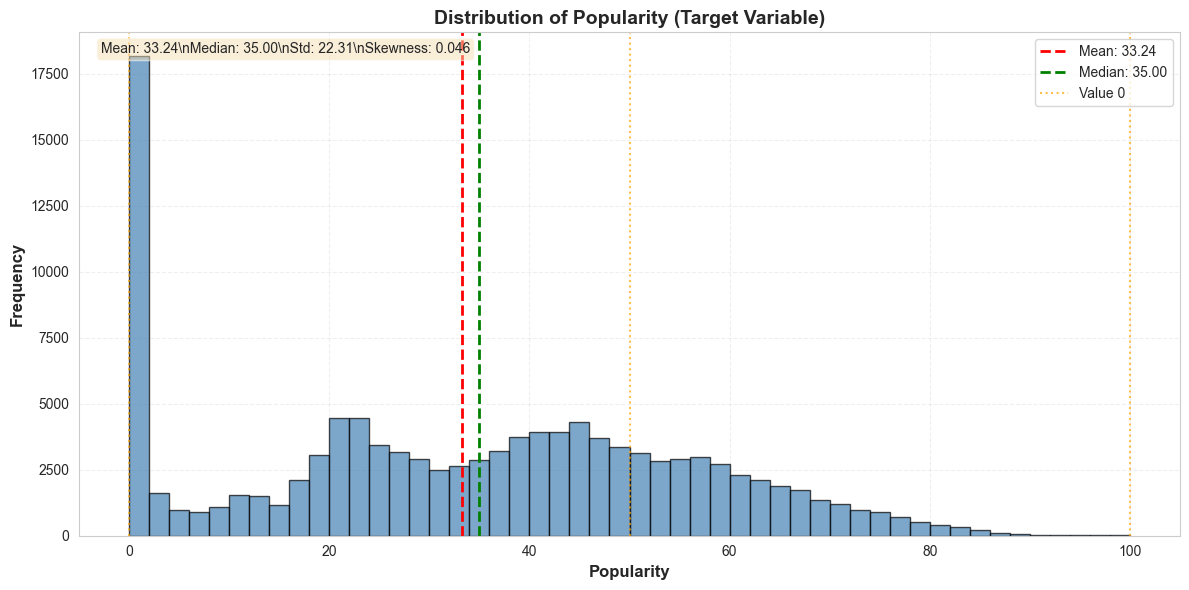


Histogram Details:
  Number of bins: 50
  Bin width: 2.00
  Total observations: 114,000


In [9]:
# ============================================================================
# Histogram of Popularity
# ============================================================================

fig, ax = plt.subplots(figsize=(12, 6))

# Create histogram with proper normalization
n_bins = 50
counts, bins, patches = ax.hist(target, bins=n_bins, edgecolor='black', alpha=0.7,
                                color='steelblue', density=False)

# Add vertical lines for mean and median
ax.axvline(mean_pop, color='red', linestyle='--', linewidth=2,
           label=f'Mean: {mean_pop:.2f}')
ax.axvline(median_pop, color='green', linestyle='--', linewidth=2,
           label=f'Median: {median_pop:.2f}')

# Add vertical lines for clustering values
for val in clustering_values:
    if val in target.values:
        ax.axvline(val, color='orange', linestyle=':', linewidth=1.5, alpha=0.7,
                  label=f'Value {val}' if val == clustering_values[0] else '')

# Labels and formatting
ax.set_xlabel('Popularity', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Popularity (Target Variable)', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')

# Add text box with statistics
textstr = f'Mean: {mean_pop:.2f}\\nMedian: {median_pop:.2f}\\nStd: {std_pop:.2f}\\nSkewness: {skewness_pop:.3f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

# Print bin information
print(f"\nHistogram Details:")
print(f"  Number of bins: {n_bins}")
print(f"  Bin width: {(bins[1] - bins[0]):.2f}")
print(f"  Total observations: {len(target):,}")

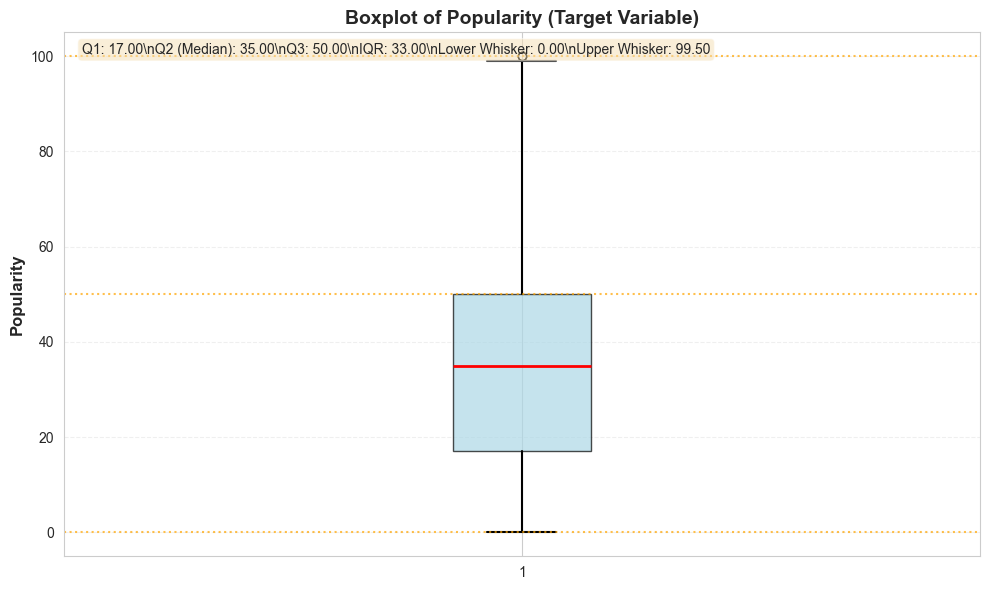


Boxplot Analysis:
  Q1 (25th percentile): 17.00
  Q2 (50th percentile / Median): 35.00
  Q3 (75th percentile): 50.00
  IQR: 33.00
  Lower whisker: 0.00
  Upper whisker: 99.50
  Outliers (beyond whiskers): 2 (0.00%)


In [10]:
# ============================================================================
# Boxplot of Popularity
# ============================================================================

fig, ax = plt.subplots(figsize=(10, 6))

# Create boxplot
bp = ax.boxplot(target, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7),
                medianprops=dict(color='red', linewidth=2),
                whiskerprops=dict(color='black', linewidth=1.5),
                capprops=dict(color='black', linewidth=1.5))

# Add labels
ax.set_ylabel('Popularity', fontsize=12, fontweight='bold')
ax.set_title('Boxplot of Popularity (Target Variable)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--', axis='y')

# Add horizontal reference lines for clustering values
for val in clustering_values:
    ax.axhline(val, color='orange', linestyle=':', linewidth=1.5, alpha=0.7)

# Calculate and display quartiles
Q1 = target.quantile(0.25)
Q3 = target.quantile(0.75)
IQR = Q3 - Q1
lower_whisker = Q1 - 1.5 * IQR
upper_whisker = Q3 + 1.5 * IQR

# Add text box with quartile information
textstr = f'Q1: {Q1:.2f}\\nQ2 (Median): {median_pop:.2f}\\nQ3: {Q3:.2f}\\nIQR: {IQR:.2f}\\nLower Whisker: {max(lower_whisker, target.min()):.2f}\\nUpper Whisker: {min(upper_whisker, target.max()):.2f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

# Identify outliers
outliers = target[(target < lower_whisker) | (target > upper_whisker)]
print(f"\nBoxplot Analysis:")
print(f"  Q1 (25th percentile): {Q1:.2f}")
print(f"  Q2 (50th percentile / Median): {median_pop:.2f}")
print(f"  Q3 (75th percentile): {Q3:.2f}")
print(f"  IQR: {IQR:.2f}")
print(f"  Lower whisker: {max(lower_whisker, target.min()):.2f}")
print(f"  Upper whisker: {min(upper_whisker, target.max()):.2f}")
print(f"  Outliers (beyond whiskers): {len(outliers):,} ({len(outliers)/len(target)*100:.2f}%)")

In [11]:
# ============================================================================
# Detailed Clustering Analysis
# ============================================================================

print("=" * 80)
print("DETAILED CLUSTERING ANALYSIS")
print("=" * 80)

# Check for clustering at 0, 50, 100
clustering_threshold = 0.01  # 1% threshold for "clustering"

for val in clustering_values:
    count = (target == val).sum()
    percentage = (count / len(target)) * 100

    print(f"\nValue {val}:")
    print(f"  Exact count: {count:,} ({percentage:.2f}%)")

    # Check nearby values (±1)
    nearby_count = ((target >= val - 1) & (target <= val + 1)).sum()
    nearby_percentage = (nearby_count / len(target)) * 100
    print(f"  Within ±1: {nearby_count:,} ({nearby_percentage:.2f}%)")

    if percentage > clustering_threshold * 100:
        print(f"  -> Significant clustering detected at this value")

# Check distribution around boundaries
print(f"\nBoundary Analysis:")
print(f"  Values at minimum (0): {(target == 0).sum():,} ({(target == 0).sum()/len(target)*100:.2f}%)")
print(f"  Values at maximum (100): {(target == 100).sum():,} ({(target == 100).sum()/len(target)*100:.2f}%)")
print(f"  Values in [0, 10]: {((target >= 0) & (target <= 10)).sum():,} ({((target >= 0) & (target <= 10)).sum()/len(target)*100:.2f}%)")
print(f"  Values in [90, 100]: {((target >= 90) & (target <= 100)).sum():,} ({((target >= 90) & (target <= 100)).sum()/len(target)*100:.2f}%)")
print(f"  Values in [45, 55]: {((target >= 45) & (target <= 55)).sum():,} ({((target >= 45) & (target <= 55)).sum()/len(target)*100:.2f}%)")

DETAILED CLUSTERING ANALYSIS

Value 0:
  Exact count: 16,020 (14.05%)
  Within ±1: 18,160 (15.93%)
  -> Significant clustering detected at this value

Value 50:
  Exact count: 1,597 (1.40%)
  Within ±1: 4,753 (4.17%)
  -> Significant clustering detected at this value

Value 100:
  Exact count: 2 (0.00%)
  Within ±1: 3 (0.00%)

Boundary Analysis:
  Values at minimum (0): 16,020 (14.05%)
  Values at maximum (100): 2 (0.00%)
  Values in [0, 10]: 23,462 (20.58%)
  Values in [90, 100]: 98 (0.09%)
  Values in [45, 55]: 17,901 (15.70%)


# Target Variable Distribution Discussion

## Guiding Questions:

1. Is regression appropriate given this distribution?

2. Is the distribution symmetric?

3. Would log transformation make sense?

4. Are there heavy tails?